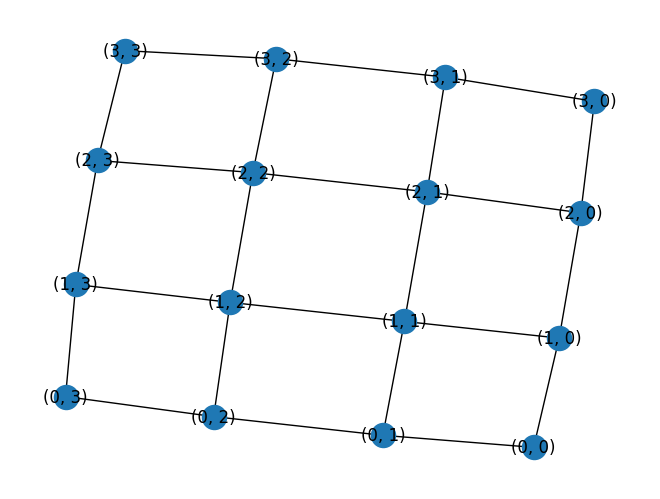

In [51]:
import random
import statistics as stats
import networkx as nx
import matplotlib.pyplot as plt

# graph topology options: k5, cycle, grid
TOPOLOGY = "grid"
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# build different graphs based on input topology
def build_graph(topology: str) -> nx.Graph:
    if topology == "k5":
        return nx.complete_graph(5)
    if topology == "cycle":
        return nx.cycle_graph(12)
    if topology == "grid":
        return nx.grid_2d_graph(4, 4)  # 4x4 grid

g = build_graph(TOPOLOGY)
nx.draw(g, with_labels=True)
plt.show()



In [52]:
# input number of colours for the topology
num_colours = 5 if TOPOLOGY == "k5" else 2

palette = ["red", "blue", "green", "orange", "yellow"]

''' 
simple conflict counting function
reads node colours and returns count of edges with same colour at eaxh end
'''
def count_conflicts(graph, colouring):
    conflicts = 0
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicts += 1
    return conflicts

'''
record of conficting nodes
store node pairs that are coflicting in the 'conflicting' set
'''
def conflicting_nodes(graph, colouring):
    conflicting = set()
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicting.add(u)
            conflicting.add(v)
    return conflicting

In [ ]:

max_steps = 200
num_runs = 20
stagnation_limit = 25      # trigger perturbation if no improvement for this many steps
perturb_fraction = 0.15    # fraction of nodes to recolour when stuck

# choose the colour that give the lowest total conflicts
# if there is a tie, pick one at random to avoid repeating the same pattern
def best_colour_with_random_tie_break(graph, colouring, node):
    current_conflicts = count_conflicts(graph, colouring)
    best_conflicts = current_conflicts
    best_colours = [colouring[node]]

    for c in range(num_colours):
        colouring[node] = c
        new_conflicts = count_conflicts(graph, colouring)

        if new_conflicts < best_conflicts:
            best_conflicts = new_conflicts
            best_colours = [c]
        elif new_conflicts == best_conflicts and c not in best_colours:
            best_colours.append(c)

    chosen = random.choice(best_colours)
    colouring[node] = chosen
    return best_conflicts

# recolours a small subset of nodes and keeps the search running
def perturb_colouring(graph, colouring):
    nodes = list(graph.nodes())
    num_changes = max(1, int(len(nodes) * perturb_fraction))
    selected = random.sample(nodes, num_changes)

    for node in selected:
        colouring[node] = random.randint(0, num_colours - 1)

# run one local search experiment and return colouring and the conflict history
def run_experiment(graph):
    # start from a random colouring
    colouring = {node: random.randint(0, num_colours - 1) for node in graph.nodes()}
    conflicts_over_time = [count_conflicts(graph, colouring)]

    steps_without_improvement = 0

    for i in range(max_steps):
        current_conflicts = conflicts_over_time[-1]

        # stop if valid colouring is found
        if current_conflicts == 0:
            break

        bad_nodes = list(conflicting_nodes(graph, colouring))

        #if no conflicting nodes, stop
        if not bad_nodes:
            break

        # update one of the conflicting node 
        node = random.choice(bad_nodes)
        previous_conflicts = current_conflicts
        new_conflicts = best_colour_with_random_tie_break(graph, colouring, node)

        conflicts_over_time.append(new_conflicts)

        # track if we improved this step
        if new_conflicts < previous_conflicts:
            steps_without_improvement = 0
        else:
            steps_without_improvement += 1

        # if stuck for too long, apply small perturbation
        if steps_without_improvement >= stagnation_limit:
            perturb_colouring(graph, colouring)
            conflicts_over_time.append(count_conflicts(graph, colouring))
            steps_without_improvement = 0

    return colouring, conflicts_over_time



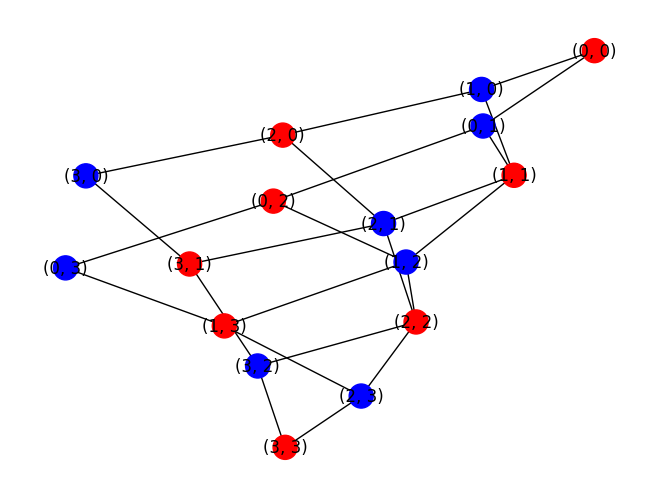

Successes: 20 / 20
Final conflicts (shown run): 0


In [ ]:

all_conflicts = []
end_conflicts = []
steps_to_solution = []
solutions = []

for i in range(num_runs):
    colouring, conflicts_over_time = run_experiment(g)
    all_conflicts.append(conflicts_over_time)
    end_conflicts.append(conflicts_over_time[-1])
    steps_to_solution.append(len(conflicts_over_time) - 1)
    solutions.append(colouring)

successes = sum(1 for c in end_conflicts if c == 0)

# choose a solved run if one exists, otherwise choose the best run
if successes > 0:
    index = next(i for i, conflicts in enumerate(end_conflicts) if conflicts == 0)
else:
    index = min(range(len(end_conflicts)), key=lambda i: end_conflicts[i])

# store solution
sample_colouring = solutions[index]

# use spring layout for plotting
node_pos = nx.spring_layout(g, seed=RANDOM_SEED)

# convert colour indices to colour names for plotting
node_colours_plot = [
    palette[sample_colouring[n]]
    for n in g.nodes()
]

# plot graph
nx.draw(g, pos=node_pos, with_labels=True, node_color=node_colours_plot)
plt.show()
print("Successes:", successes, "/", num_runs)
print("Final conflicts (shown run):", end_conflicts[index])



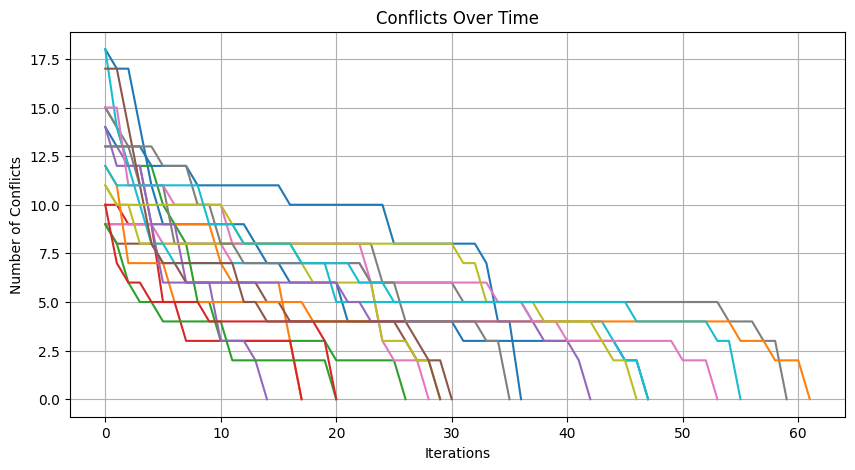

In [55]:
# plot conflict over time for runs
plt.figure(figsize=(10, 5))
for conflicts in all_conflicts:
    plt.plot(conflicts)

plt.title("Conflicts Over Time")
plt.xlabel("Iterations")
plt.ylabel("Number of Conflicts")
plt.grid(True)
plt.show()